### Lab 5.1: Convolutional Neural Networks in PyTorch

In this lab you will explore how to create a convolutional neural network (CNN) with PyTorch.

The CNN will run slowly unless you have an accelerator (like on newer MacBooks or in Google Colab).  On Colab, make sure to select the GPU runtime in `Runtime > Change runtime type`.

Here I load the Intel Image Classification dataset.  The images have been resized to 32x32.

In [23]:
!test -f intel_image_classification.npz || (curl -sSfL -o intel_image_classification.npz.part "https://www.dropbox.com/scl/fi/g8piaiw6njhogb7fnu7b3/intel_image_classification.npz?rlkey=8ytc0ucpc7tg2gzs0gxtnzun5&dl=1" && mv intel_image_classification.npz.part intel_image_classification.npz)

In [24]:
import numpy as np
from matplotlib import pyplot as plt

In [25]:
data = np.load('intel_image_classification.npz')
label_names = data['label_names']
X_train = data['X_train']
y_train = data['y_train']
X_test = data['X_test']
y_test = data['y_test']

The dataset has six categories and around 16k images total.

In [26]:
label_names

array(['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street'],
      dtype='<U9')

In [27]:
X_train.shape, X_train.dtype, X_train.min(), X_train.max()

((13986, 32, 32, 3), dtype('float32'), np.float32(0.0), np.float32(1.0))

In [28]:
y_train.shape, y_train.dtype, y_train.min(), y_train.max()

((13986,), dtype('int64'), np.int64(0), np.int64(5))

In [29]:
len(X_train), len(X_test)

(13986, 2993)

Text(0.5, 1.0, '0')

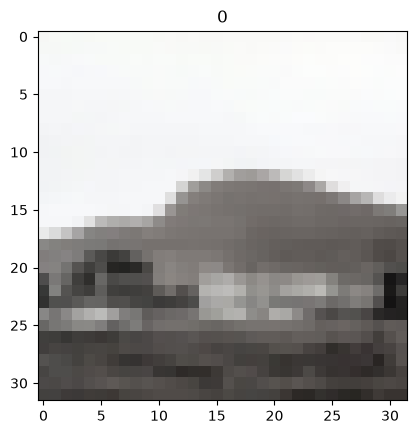

In [30]:
plt.imshow(X_train[0])
plt.title(y_train[0])

In [31]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [32]:
X_train_torch = torch.tensor(X_train.transpose((0,3,1,2))) # change dim ordering for PyTorch
y_train_torch = torch.tensor(y_train)
X_test_torch = torch.tensor(X_test.transpose((0,3,1,2))) # change dim ordering for PyTorch
y_test_torch = torch.tensor(y_test)

## Exercises

Create a CNN to classify the images.  Here is a starting point for your architecture, although you are free to put whatever you want into the network:

* Input layer
* 2D convolution, 3x3 kernel, 32 channels, ReLU activation
* Max pooling: 2x2 kernel, stride of 2
* 2D convolution, 3x3 kernel, 64 channels, ReLU activation
* Max pooling: 2x2 kernel, stride of 2
* 2D convolution, 3x3 kernel, 128 channels, ReLU activation
* Max pooling: 2x2 kernel, stride of 2
* Flatten
* Linear layer: 6 outputs

Choose some settings for the optimizer etc. and see what accuracy can you achieve on this dataset.

In [33]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

train_loader = DataLoader(TensorDataset(X_train_torch, y_train_torch), batch_size=64, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_torch,  y_test_torch),  batch_size=64, shuffle=False)


model = nn.Sequential(
    nn.Conv2d(3, 32, 3, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),
    nn.Conv2d(32, 64, 3, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),
    nn.Conv2d(64, 128, 3, padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),
    nn.Flatten(),
    nn.Dropout(0.5),
    nn.Linear(128 * 4 * 4, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256,6)
).to(device)

opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay = 1e-4)
loss_func = nn.CrossEntropyLoss()

In [35]:
for epoch in range(20):
    model.train()
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        opt.zero_grad()
        loss = loss_func(model(X_batch), y_batch)
        loss.backward()
        opt.step()

    model.eval()
    correct = total = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = model(X_batch).argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)
    print(f"epoch {epoch}  loss {loss.item():.3f}  test acc {correct/total:.4f}")

epoch 0  loss 0.666  test acc 0.7765
epoch 1  loss 0.623  test acc 0.8199
epoch 2  loss 0.309  test acc 0.7982
epoch 3  loss 0.503  test acc 0.8286
epoch 4  loss 0.405  test acc 0.8055
epoch 5  loss 0.260  test acc 0.7407
epoch 6  loss 0.481  test acc 0.7979
epoch 7  loss 0.323  test acc 0.8319
epoch 8  loss 0.409  test acc 0.6091
epoch 9  loss 0.201  test acc 0.8206
epoch 10  loss 0.318  test acc 0.6980
epoch 11  loss 0.325  test acc 0.8156
epoch 12  loss 0.375  test acc 0.7685
epoch 13  loss 0.182  test acc 0.8212
epoch 14  loss 0.204  test acc 0.8443
epoch 15  loss 0.457  test acc 0.7832
epoch 16  loss 0.442  test acc 0.7888
epoch 17  loss 0.522  test acc 0.7925
epoch 18  loss 0.493  test acc 0.8306
epoch 19  loss 0.362  test acc 0.7918
